# Computational Intelligence Project: Island Genetic Algorithm

This notebook demonstrates the incremental implementation of an advanced Genetic Algorithm (GA) to solve a variation of the Vehicle Routing Problem (VRP) with non-linear costs. 

## The Problem
We need to collect gold from $N$ cities and return it to a base (0). 
**Cost Function**: $c(d, w) = d + (\alpha \cdot d \cdot w)^\beta$

Where $\beta$ can be high (e.g., 5.0), making heavy loads extremely expensive over distance.

In [1]:
import logging
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict

# Import from our unified codebase
from problem import Problem
from src.solver import GA_Solver

logging.basicConfig(level=logging.INFO, format='%(message)s')

## 1. Problem Definition
We use the shared `Problem` class to generate the graph and calculate costs.

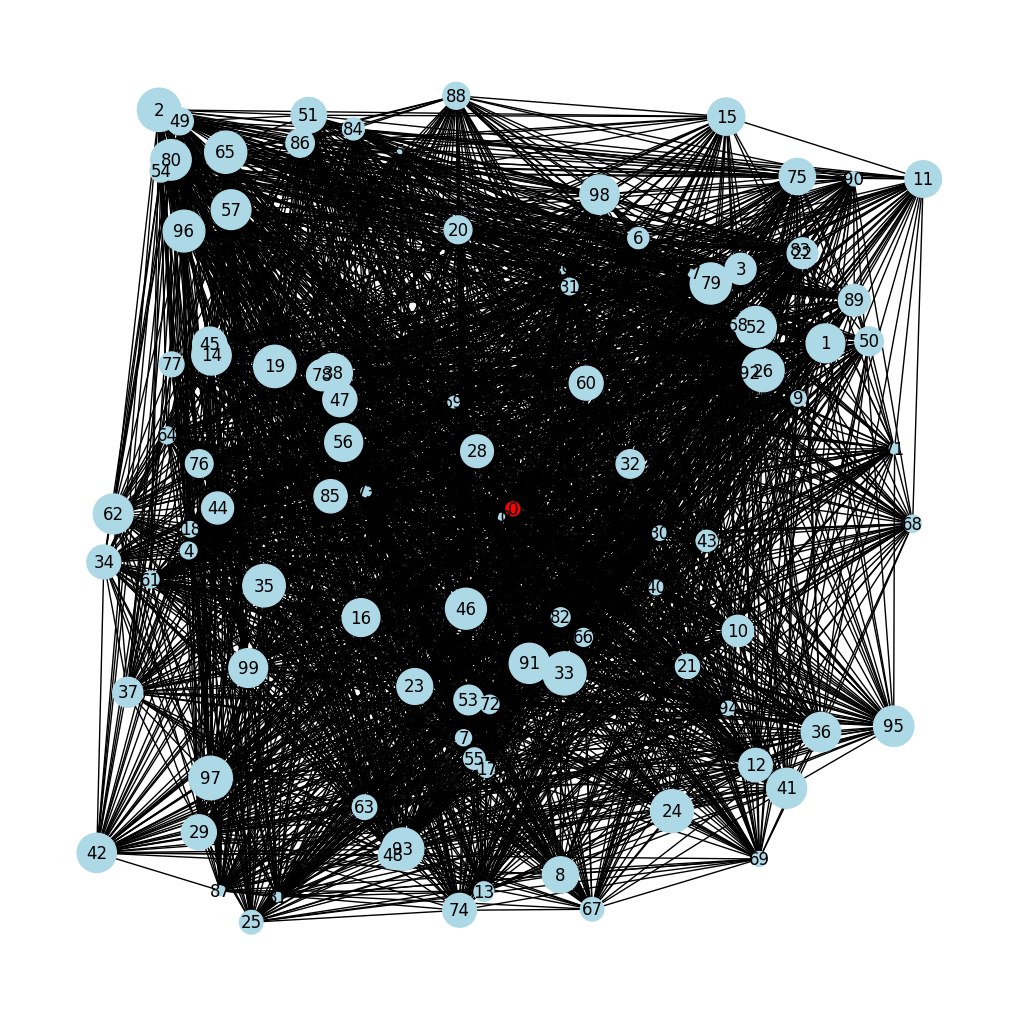

In [2]:
# Initialize Problem
problem = Problem(num_cities=100, alpha=0.3,beta=0.2,density=0.5, seed=42)
problem.plot()
plt.show()

### 1.1 Problem Baseline

In [3]:
baseline_cost = problem.baseline()
print(f"Baseline Cost: {baseline_cost:.2e}")

Baseline Cost: 3.64e+02


## 2. Solution Strategy: Island GA + Virtual Nodes
We use the `GA_Solver` class which encapsulates:
1.  **Virtual Nodes**: Splitting heavy cities.
2.  **Island Model**: 4 distinct populations (Exploit, Balanced, Explore, Chaos).
3.  **Adaptive Parameters**: Evolving mutation rates and window sizes.

We will run the solver step-by-step.

In [4]:
# Initialize Solver
solver = GA_Solver(problem, pop_size_per_island=80)

print(f"Initial Best Cost: {solver.global_best.cost:.2e}")

Initial Best Cost: 2.23e+02


## 3. Running the Evolution
We can step through generations and observe the convergence.

In [5]:
generations = 100
history = {'gen': [], 'best_cost': []}

for g in range(generations):
    stats = solver.step_generation()
    
    history['gen'].append(stats['gen'])
    history['best_cost'].append(stats['best_cost'])
    
    if g % 10 == 0:
        print(f"Gen {g}: Best Cost {stats['best_cost']:.4e}")

Gen 0: Best Cost 2.2266e+02
Gen 10: Best Cost 2.2139e+02
Gen 20: Best Cost 2.2048e+02
Gen 30: Best Cost 2.2015e+02
Gen 40: Best Cost 2.1982e+02
Gen 50: Best Cost 2.1920e+02
Gen 60: Best Cost 2.1893e+02
Gen 70: Best Cost 2.1891e+02
Gen 80: Best Cost 2.1879e+02
Gen 90: Best Cost 2.1860e+02


In [7]:
best_ind = solver.global_best
formatted_solution = []
        
# best_ind.trips is a list of lists, e.g., [[v1, v2], [v3, v4]]
for trip in best_ind.trips:
    for v_node in trip:
            # Map virtual node ID back to real city ID
        real_node = solver.virtual_map[v_node]
            # distinct gold amount for this specific virtual chunk
        gold_amount = solver.node_golds[v_node]
                
        formatted_solution.append((real_node, gold_amount))
            
    # Append "Return to Base" (City 0, 0 Gold) after every trip
    formatted_solution.append((0, 0))

In [8]:
formatted_solution

[(70, 22.126868320103593),
 (0, 0),
 (37, 467.9142199537362),
 (25, 287.15978065517294),
 (29, 634.3411365694041),
 (97, 979.5911099060061),
 (0, 0),
 (63, 311.0243392501504),
 (74, 591.5526722948603),
 (13, 200.57587600839756),
 (48, 413.15899770440666),
 (93, 924.917027149044),
 (0, 0),
 (17, 131.92669380575595),
 (0, 0),
 (81, 44.43158695077915),
 (87, 50.204865807666394),
 (42, 797.0202712368366),
 (99, 779.6980632305576),
 (0, 0),
 (95, 843.731376646155),
 (0, 0),
 (68, 154.45978179686657),
 (90, 102.57023100081226),
 (75, 681.0338122727069),
 (22, 489.0954613061818),
 (0, 0),
 (73, 54.32855069454821),
 (85, 571.66141909103),
 (0, 0),
 (40, 110.0348527689692),
 (0, 0),
 (32, 419.6952049969875),
 (0, 0),
 (47, 603.5040501813869),
 (56, 746.2682659632029),
 (0, 0),
 (59, 67.49229809822297),
 (28, 555.6428442844979),
 (0, 0),
 (49, 374.8098593637755),
 (54, 248.59172338840676),
 (96, 902.7504907836894),
 (2, 971.8545996349064),
 (57, 816.7521946604865),
 (65, 921.0495020149627),
 (80

In [9]:
print(f"\nFinal Solution Cost: {solver.global_best.cost:.4e}")

print(f"Returned base {formatted_solution.count((0, 0))-1} times")


Final Solution Cost: 2.1841e+02
Returned base 28 times


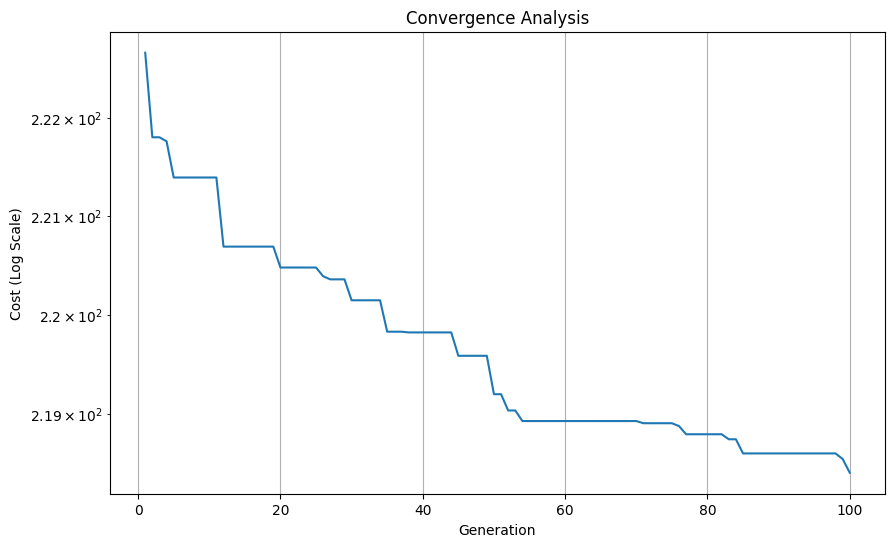

In [10]:
# Plot Convergence
plt.figure(figsize=(10, 6))
plt.plot(history['gen'], history['best_cost'])
plt.yscale('log')
plt.title('Convergence Analysis')
plt.xlabel('Generation')
plt.ylabel('Cost (Log Scale)')
plt.grid(True)
plt.show()

## 4. Comparison with Baseline
We compare our result against the simple Dijkstra baseline.

In [11]:
baseline_cost = problem.baseline()
print(f"Baseline Cost: {baseline_cost:.2e}")
print(f"My Solution Cost: {solver.global_best.cost:.2e}")

if solver.global_best.cost < baseline_cost:
    factor = baseline_cost / solver.global_best.cost
    print(f"Improvement Factor: {factor:.5f}x better")
else:
    print("No improvement.")

Baseline Cost: 3.64e+02
My Solution Cost: 2.18e+02
Improvement Factor: 1.66552x better


# 5. Full Experimentation

I'm definitely way stronger than baseline when Beta is high but the same solution seems to be stuck in local optima when Beta = 1. We have to make our split count (how much we return to base), our tour mechanics (are we starting from the furher cities, or the nearest cities), and our chunking (are we splitting the tour into chunks, or are we just doing one big tour) more adaptive to the problem.

To do this, I need to first analyze the statistics of my solution with an experimentation grid.

In [5]:
import sys
import os
import csv

from problem import Problem
from s347896 import solution

In [6]:
# Experiment Parameters
DENSITIES = [0.05,0.20,0.60,0.95]
BETAS = [0.01,0.1,1,1.2]
NUM_CITIES_LIST = [10]

# Prepare CSV file
csv_columns = ["graph_density", "beta", "num_cities", "split_count", "improvement_factor", "tour_sequence", "distances_between_cities", "gold_carried_at_each_step", "status", "error"]
csv_file = "mechanics_analysis.csv"

# Collect plot data as we go
plot_data = {} 

In [7]:
def calculate_metrics(p, formatted_solution, baseline_cost):
    """Calculates requested mechanics metrics."""
    split_count = 0
    distances = []
    gold_carried = []
    
    current_gold = 0
    
    path_nodes = []
    for node_id, gold_amt in formatted_solution:
         path_nodes.append(node_id)
         
         if node_id == 0:
             split_count += 1
             current_gold = 0 # Reset load at base
         else:
             current_gold += gold_amt
         
         gold_carried.append(float(current_gold))

    g = p.graph
    
    # Calculate distances
    for i in range(len(path_nodes) - 1):
        u = path_nodes[i]
        v = path_nodes[i+1]
        
        if g.has_edge(u, v):
            dist = g[u][v]['dist']
        else:
            try:
                dist = nx.shortest_path_length(g, u, v, weight='dist')
            except nx.NetworkXNoPath:
                dist = float('inf')
        
        distances.append(float(dist))

    # Approximate GA cost for improvement calc
    ga_cost = 0
    curr_load = 0
    current_node = 0 
    
    for (next_node, gold_amt) in formatted_solution:
        try:
             step_path = nx.shortest_path(g, current_node, next_node, weight='dist')
             step_cost = p.cost(step_path, curr_load)
             ga_cost += step_cost
        except:
             pass 
             
        if next_node == 0:
            curr_load = 0 
        else:
            curr_load += gold_amt 
            
        current_node = next_node

    improvement = baseline_cost / ga_cost if ga_cost > 0 else 0.0

    return split_count, distances, gold_carried, improvement

Starting Analysis Experiments... Saving to mechanics_analysis.csv

Instance: N=10, A=1.0, B=0.0, D=0.22
Complexity Score: 2.18
Config: Budget=4361 | Pop=99 (33/isl) | Gens=44
Completed N=10, D=0.05, B=0.01 -> Imp=4.1797x

Instance: N=10, A=1.0, B=0.1, D=0.22
Complexity Score: 2.22
Config: Budget=4440 | Pop=99 (33/isl) | Gens=44
Completed N=10, D=0.05, B=0.1 -> Imp=3.724x

Instance: N=10, A=1.0, B=1.0, D=0.22
Complexity Score: 2.61
Config: Budget=5223 | Pop=99 (33/isl) | Gens=52
Completed N=10, D=0.05, B=1 -> Imp=1.0022x

Instance: N=10, A=1.0, B=1.2, D=0.22
Complexity Score: 2.70
Config: Budget=5397 | Pop=94 (31/isl) | Gens=57
Completed N=10, D=0.05, B=1.2 -> Imp=1.4383x

Instance: N=10, A=1.0, B=0.0, D=0.33
Complexity Score: 1.89
Config: Budget=3787 | Pop=99 (33/isl) | Gens=38
Completed N=10, D=0.2, B=0.01 -> Imp=2.5811x

Instance: N=10, A=1.0, B=0.1, D=0.33
Complexity Score: 1.93
Config: Budget=3855 | Pop=99 (33/isl) | Gens=38
Completed N=10, D=0.2, B=0.1 -> Imp=2.2332x

Instance: N=

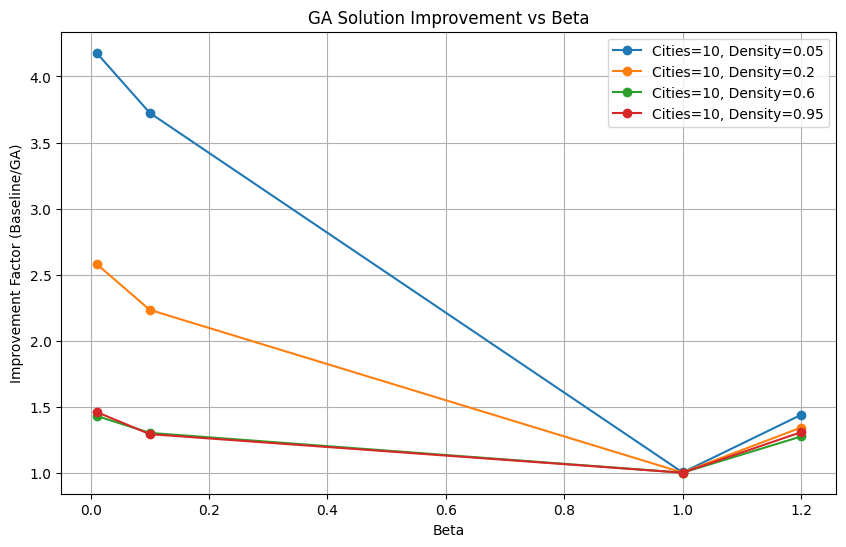

In [8]:
print(f"Starting Analysis Experiments... Saving to {csv_file}")

with open(csv_file, 'w', newline='') as csvfile:
    writer = csv.DictWriter(csvfile, fieldnames=csv_columns)
    writer.writeheader()

    for num_cities in NUM_CITIES_LIST:
        for density in DENSITIES:
            for beta in BETAS:
                # Basic row info
                row = {
                    "graph_density": density,
                    "beta": beta,
                    "num_cities": num_cities,
                    "split_count": 0,
                    "improvement_factor": 0.0,
                    "tour_sequence": "",
                    "distances_between_cities": "",
                    "gold_carried_at_each_step": "",
                    "status": "pending",
                    "error": ""
                }
                
                try:
                    p = Problem(num_cities, alpha=1.0, beta=beta, density=density, seed=42)
                    baseline_c = p.baseline()
                    
                    # Run GA Solution
                    sol_seq = solution(p)
                    
                    # Metrics
                    splits, dists, golds, imp = calculate_metrics(p, sol_seq, baseline_c)
                    
                    row.update({
                        "split_count": splits,
                        "improvement_factor": round(imp, 4),
                        # Store complex lists as JSON-like strings
                        "tour_sequence": str([int(x[0]) for x in sol_seq]),
                        "distances_between_cities": str([round(x, 4) for x in dists]),
                        "gold_carried_at_each_step": str([round(x, 4) for x in golds]),
                        "status": "success",
                        "error": ""
                    })
                    
                    # Store for plotting
                    group_key = (density, num_cities)
                    if group_key not in plot_data:
                        plot_data[group_key] = {'x': [], 'y': []}
                    plot_data[group_key]['x'].append(beta)
                    plot_data[group_key]['y'].append(imp)
                    
                    # Print small progress indicator
                    print(f"Completed N={num_cities}, D={density}, B={beta} -> Imp={round(imp, 4)}x", flush=True)

                except Exception as ex:
                    row.update({
                        "status": "failure",
                        "error": str(ex)
                    })
                    print(f"Failed N={num_cities}, D={density}, B={beta}: {ex}", flush=True)
                
                writer.writerow(row)

# Plotting
plt.figure(figsize=(10, 6))
for (density, num_c), data in plot_data.items():
    # Sort by beta just in case
    sorted_pairs = sorted(zip(data['x'], data['y']))
    xs = [x[0] for x in sorted_pairs]
    ys = [x[1] for x in sorted_pairs]
    plt.plot(xs, ys, marker='o', label=f"Cities={num_c}, Density={density}")

plt.xlabel('Beta')
plt.ylabel('Improvement Factor (Baseline/GA)')
plt.title('GA Solution Improvement vs Beta')
plt.legend()
plt.grid(True)
plt.savefig('improvement_vs_beta.png')
print("Analysis complete. Plot saved to improvement_vs_beta.png")

### 5.1 Why is Improvement Factor ~1 when Beta=1?

When $ \beta = 1 $ , the cost function roughly scales linearly with weight:  

$\text{Cost ≈ Dist + (Alpha * Dist * Weight)}$

The baseline algorithm executes a **Dedicated Trip** strategy: for every city, it goes Base -> City -> Base along the shortest path.

For Beta=1, my solver does not create virtual nodes (chunks), so it treats cities as atomic. While the GA can chain cities (Base -> A -> B -> Base), the linear penalty of carrying Gold(A) while traveling to B often outweighs the distance savings of not returning to base, especially if Alpha is high.

## 5.2 How does Density affect Improvement?

- Trend: Lower density ($D=0.3$) yields higher improvement factors, especially at high $\beta$.
- Why: In sparse graphs, "Dedicated Trips" (Baseline) are punished because direct paths don't exist; the agent must take long detours for every single trip.
- GA Advantage: Our GA chains cities (Route First). By visiting a cluster of cities in one go, it pays the "detour cost" from the Base only once for the whole group, rather than once per city. This geometric efficiency is magnified in sparse graphs.

# 6. Making Mechanics More Adaptive

We want to adapt Split Count, Tour Mechanics, and Chunking to the problem instance.

**1. Adaptive Chunking (Virtual Nodes)**

- Current: Calculated once at initialization using heuristics (S, density_factor).
- Issue: If the heuristic misses (e.g., chunks are too big), we pay a huge beta penalty. If too small, the genome becomes massive and hard to solve.
- Idea: Instead of fixed chunk sizes:
    - Small gold → no split
    - Medium gold → 2–3 chunks
    - Large gold → adaptive chunking based on:
        - α
        - β
        - Number of cities
        - average edge length etc. (maybe)
- Idea 2: Can we make win_base or the chunk size dynamic? 
    - We could run a "Pre-check" phase: Generate a few varied chunk sizes, run a quick greedy lap, and pick the chunking granularity that gives the best start.


This prevents genome bloat and speeds convergence.

**2. Adaptive Split Count (Return to Base)**
- Current: Controlled by split_route algorithm. It finds the mathematically optimal split for a given sequence.
- Improvement: The limitation isn't the splitter, it's the Sequence. If the GA generates a sequence Far -> Near -> Far, the splitter is forced to return often.
- Idea-1: The Island roles (Exploit, Explore) are good, but we could add a "Geometric" Island.
    - Mechanism: An island that explicitly initializes/mutates populations based on clustering (e.g., K-Means centroids) rather than just random swaps. This "groups" cities in the genome, allowing the splitter to make one efficient trip per group.

- Idea-2: Use split-aware crossover (small but powerful)
    - Ensure crossover preserves:
        - relative ordering of chunks from the same city or at least locality

**3. Adaptive Tour Mechanics (Initialization)**
-  We use sorted (Furthest cities first) for 10% of pop because it's a good strategy for many problems. However, not all problems.
- Idea: Add "Nearest First" and "Cheapest First" initialization.
    - Nearest First: Good for "sweeping" the graph.
    - Cheapest First (Low gold): Keeps weight low provided Beta is high.